# Advanced Chemical Reaction Engineering (CBE 60546)
## Homework 9
## Due December 11, 2025

Carefully and neatly document your answers. Use Jupyter/Collab for all plots. See sample code at https://github.com/wmfschneider/CBE60546/blob/main/Resources/Examples.ipynb.

# Pushing to the limit
Consider the liquid-phase, autocatalytic reaction

$$\ce{2 A -> B},\ \ \ \ r=kC_A C_B\ \ \ \ k(300\text{ K}) = 0.5 \text{M}^{-1} \text{s}^{-1}$$

The reaction enthalpy and volumetric heat capacity are  $\Delta H_\text{rxn} = -200$ kJ/mol and $\rho \bar{C}_p = 4000$ J/l/K, respectively, and are roughly temperature-independent. The reaction follows Arrhenius kinetics and the rate constant at 310 K is twice that of 300 K. You have a feed containing 0.2 M B and 2.0 M A.

### Q1. Determine the reaction activation energy and prefactor.

From

$
\ln\left(\frac{k_2}{k_1}\right)
= -\frac{E_a}{R}\left(\frac{1}{T_2} - \frac{1}{T_1}\right)
$

---

### **Activation Energy $E_a$**

Plug in the given values and find for $E_a$

$
\ln(2) = -\frac{E_a}{8.314}\left(\frac{1}{321 K} - \frac{1}{300 K}\right)
$

$
\boxed{
E_a \approx 53.6\ \text{kJ mol}^{-1}}
$

---

### **Prefactor A**

Use $k(300\ \text{K}) = 0.5\ \text{M}^{-1}\text{s}^{-1}$:

$
A = k_1 \exp\left(\frac{E_a}{RT_1}\right)
$

$
A = 0.5 \exp\left(\frac{5.36\times 10^{4}}
{8.314 \times 300}\right)
$

$
\boxed{
A \approx 1.07\times 10^{9}\ \text{M}^{-1}\text{s}^{-1}}
$

### Q2. Suppose you run the reaction in an isothermal PFR at 300 K. Plot conversion vs reactor space time. 

We need to derive $X(\tau)$

From $\frac{dC_A}{d\tau}=r_A=-2kC_AC_B$

***Stoichiometry for $2A \to B$ at constant volume gives***

$
C_A = C_{A0}(1-X), \qquad
C_B = C_{B0} + \frac{C_{A0}}{2}X
$

So

$
\frac{d}{d\tau}C_{A0}(1-X)
= -2kC_{A0}(1-X)(C_{B0}+\frac{C_{A0}}{2}X)
$

$
\boxed{
\frac{dX}{d\tau}=2k(1-X)(C_{B0}+\frac{C_{A0}}{2}X)}
$

Text(0.5, 1.0, 'Isothermal conversion vs reactor volume')

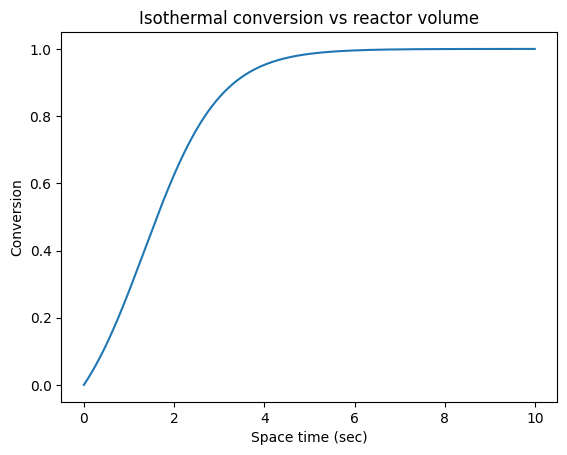

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp, simpson, quad

R0 = 8.31441 # J/mol K

def CA(X):
    return CA0*(1-X)

def CB(X):
    return CB0+CA0/2*X

def rate_iso(X,k):
    return k*CA(X)*CB(X)

def dXdtau_isothermal(X,t,k0):
    dXdtau = 2*k0*(1-X[0])*(CB0+CA0/2*X[0])
    return dXdtau

V      = 10      # liter
CA0    = 2.0     # M
CB0    = 0.2
k300   = 0.5    # /sec
deltaH = -200000  # J/mol
max_conversion = 0.9

tau = 10
v0  = V/tau

t = np.arange(0,tau,.01) 
X0 = [0]

p=(k300,)

Conversion = odeint(dXdtau_isothermal,X0,t,p)

Xiso = Conversion.transpose()[0]
Volume = t * v0

plt.figure()
plt.plot(t,Xiso)
plt.xlabel('Space time (sec)')
plt.ylabel('Conversion')
plt.title('Isothermal conversion vs reactor volume')

### Q3. What space time is necessary to achieve 90% conversion of A?

In [2]:
def inv_rate_isothermal(X):
    k0 = k300
    inv_rate_iso = 1./(k0*CA(X)*CB(X))
    return inv_rate_iso

tau90=quad(inv_rate_isothermal,0,0.9)
print(f"Isothermal reactor volume to 90% conversion = {tau90[0]*v0:.2f} l")
print(f"Isothermal reactor space time to 90% conversion = {tau90[0]:.2f} sec")

Isothermal reactor volume to 90% conversion = 3.34 l
Isothermal reactor space time to 90% conversion = 3.34 sec


In [3]:
# Alternative way to find X=0.9
idx = np.argmin(np.abs(Xiso - 0.9))
print(f"Isothermal reactor space time to 90% conversion = {t[idx]:.2f} sec")

Isothermal reactor space time to 90% conversion = 3.34 sec


### Q4. How much total heat removal (in W) is necessary to maintain isothermal operation?

From the lecture, for an isothermal PFR:

$
\frac{d\dot Q}{dV} = r(-\Delta H_{\text{rxn}})
$

Text(0, 0.5, 'Isothermal heat removal (W/liter)')

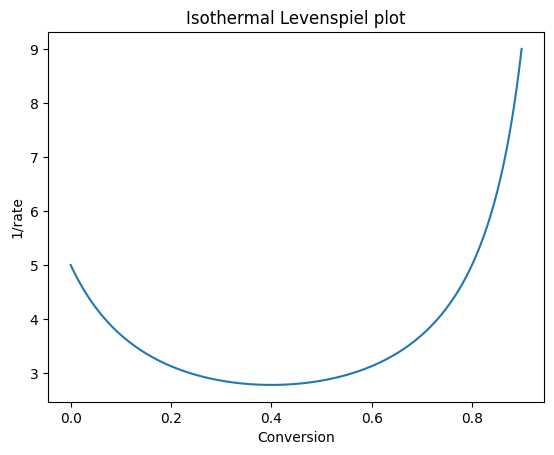

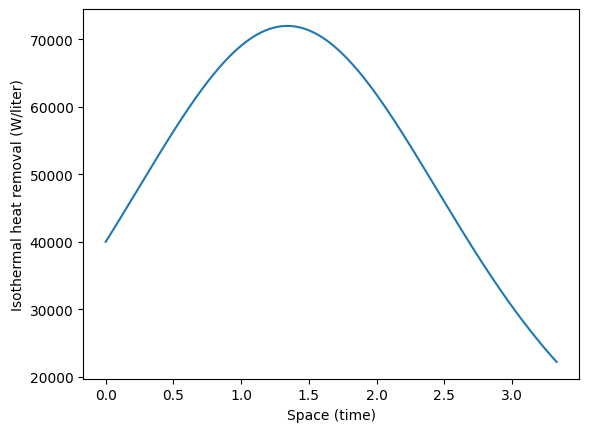

In [4]:
rate_isothermal = rate_iso(Xiso[:idx],k300)
plt.figure()
plt.plot(Xiso[:idx],1./rate_isothermal)
plt.title('Isothermal Levenspiel plot')
plt.xlabel('Conversion')
plt.ylabel('1/rate')

Qdot = -rate_isothermal*deltaH
plt.figure()
plt.plot(t[:idx],Qdot)
plt.xlabel('Space (time)')
plt.ylabel('Isothermal heat removal (W/liter)')

In [5]:
total_heat_removal = simpson(Qdot,Volume[:idx])
print(f"Total heat removal = {total_heat_removal/60:.0f} W")

Total heat removal = 2997 W


### Q5. You decide the space time is much too large for your liking, so you insulate the PFR and try again. Plot conversion vs reactor space time assuming adiabatic operation.

Linear relationship between T and X (in lecture 9)

$
T=T_0+\frac{\Delta H_{rxn}}{\nu_A}(\frac{C_{A0}}{\rho C_P})*X
$

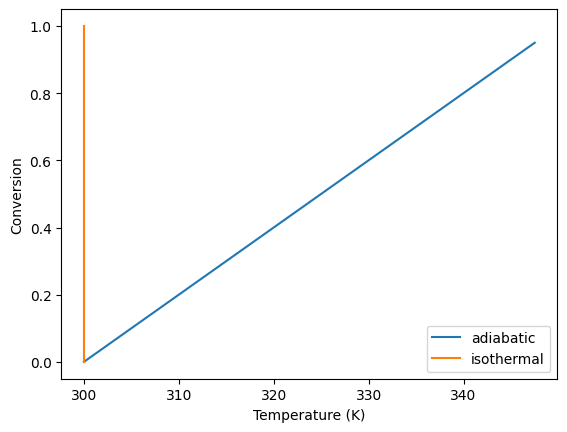

In [6]:
def T_adiabatic(X):
    return T0 - (CA0 * deltaH/rhoCp)/2*X

def k(T):
    A = 1.07e9 # /sec
    Ea = 53.6e3 # J/mol
    k = A*np.exp(-Ea/(R0*T))
    return k

def dXdtau_adiabatic(X,t):
    Temperature = T_adiabatic(X[0])
    k0 = k(Temperature)
    dXdtau = 2*k0*(1-X[0])*(CB0+CA0/2*X[0])
    return dXdtau

def rate_adiabatic(X):
    Temperature = T_adiabatic(X)
    k0 = k(Temperature)
    rate_adi = k0*CA(X)*CB(X)
    return rate_adi

def inv_rate_adiabatic(X):
    Temperature = T_adiabatic(X)
    k0 = k(Temperature)
    inv_rate_adi = 1./(k0*CA(X)*CB(X))
    return inv_rate_adi

rhoCp  = 4000    # J/l K
T0     = 300     # K

X = np.arange(0,1,0.05)

plt.figure()
plt.plot(T_adiabatic(X),X,label='adiabatic')
plt.plot([T0,T0],[0,1],label='isothermal')
plt.xlabel('Temperature (K)')
plt.ylabel('Conversion')
plt.legend()

Text(0, 0.5, '1/rate')

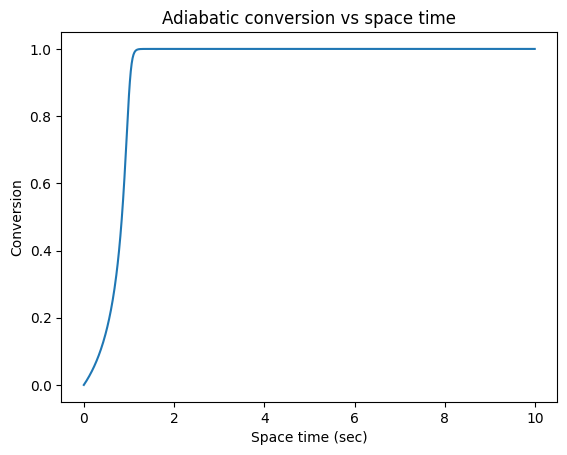

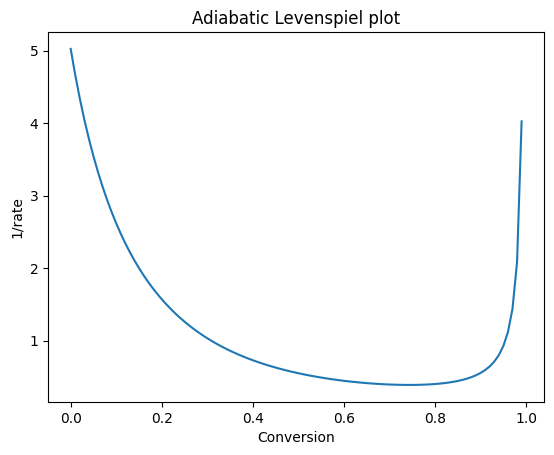

In [7]:
X0 = [0]
p = ()
t = np.arange(0,tau,.01) 
Conversion = odeint(dXdtau_adiabatic,X0,t,p)

Xadi = Conversion.transpose()[0]
Volume = t * v0

plt.figure()
plt.plot(t,Xadi)
plt.xlabel('Space time (sec)')
plt.ylabel('Conversion')
plt.title('Adiabatic conversion vs space time')

Xl = np.arange(0,0.9999,0.01)
plt.figure()
plt.plot(Xl,1./rate_adiabatic(Xl))
plt.title('Adiabatic Levenspiel plot')
plt.xlabel('Conversion')
plt.ylabel('1/rate')

### Q6. What space time is needed to reach 90% conversion now?

In [8]:
tau90=quad(inv_rate_adiabatic,0,0.9)
print(f"Adiabatic reactor volume to 90% conversion = {tau90[0]*v0:.2f} l")
print(f"Adiabatic reactor space time to 90% conversion = {tau90[0]:.2f} sec")

Adiabatic reactor volume to 90% conversion = 1.02 l
Adiabatic reactor space time to 90% conversion = 1.02 sec


### Q7. What is the temperature of the exiting product stream?

In [9]:
T_adiabatic(0.9)

345.0

### Q8. Yikes, that's too hot! The solvent boils at that temperature. How could you operate the reactor, keeping conversion at 90%, and keeping maximum temperature $< 323$ K?

Text(0, 0.5, 'Conversion')

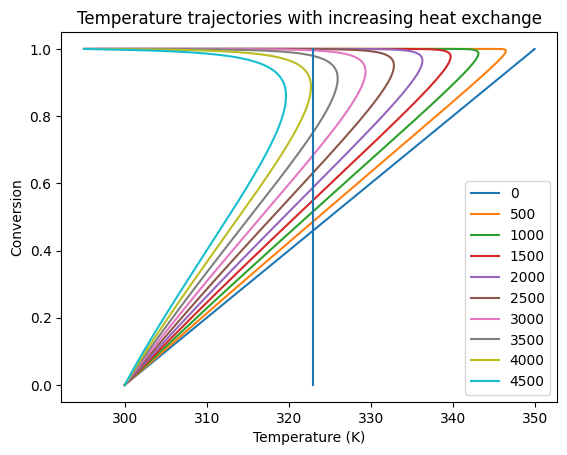

In [10]:
def rate_hx(X,T):
    k0 = k(T)
    rate_hx= k0*CA(X)*CB(X)
    return rate_hx

def dfdtau(f,t,Ua): # f is a vector of X and T
    rate = rate_hx(f[0],f[1])
    dXdtau = 2*rate_hx(f[0],f[1])/CA0
    dTdtau = (-deltaH * rate - Ua *(f[1]-Text))/rhoCp
    dfdtau = [dXdtau,dTdtau] 
    return dfdtau

Text = 295  # K
T0 = 300   # K
CA0 = 2.0  # M
CB0 = 0.2  # M
tau = 10

t = np.arange(0,tau,.01) 

plt.figure()
for Ua in range(0,5000,500):  # W/K
    p = (Ua,)
    f0=(0,T0)
    state = odeint(dfdtau,f0,t,p)
    Xhx = state.transpose()[0]
    Thx = state.transpose()[1]
    plt.plot(Thx,Xhx,label=Ua)
plt.plot([323,323],[0,1])
plt.legend()
plt.title("Temperature trajectories with increasing heat exchange")
plt.xlabel("Temperature (K)")
plt.ylabel("Conversion")

Text(0, 0.5, 'Temperature (K)')

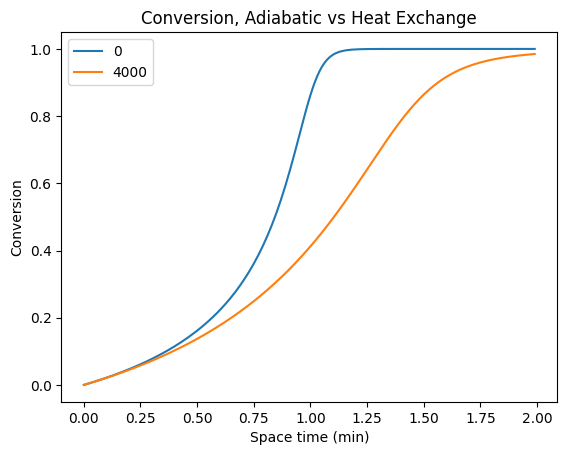

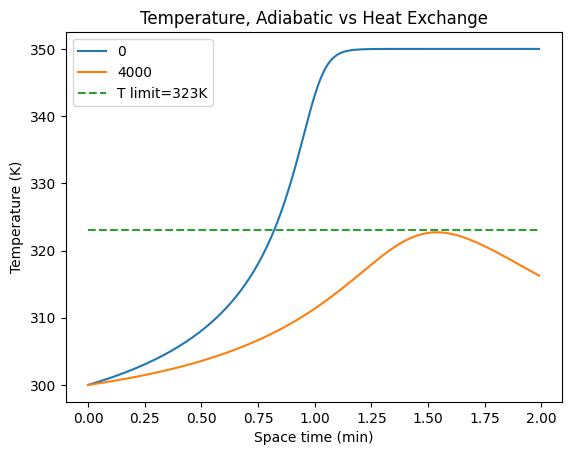

In [11]:
t = np.arange(0,tau/5,.01) 
plt.figure()
for Ua in (0,4000):  # W/K
    p = (Ua,)
    f0=(0,T0)
    state = odeint(dfdtau,f0,t,p)
    Xhx = state.transpose()[0]
    Thx = state.transpose()[1]
    plt.plot(t,Xhx,label=Ua)

plt.legend()
plt.title("Conversion, Adiabatic vs Heat Exchange")
plt.xlabel("Space time (min)")
plt.ylabel("Conversion")

t = np.arange(0,tau/5,.01) 
plt.figure()
for Ua in (0,4000):  # W/K
    p = (Ua,)
    f0=(0,T0)
    state = odeint(dfdtau,f0,t,p)
    Xhx = state.transpose()[0]
    Thx = state.transpose()[1]
    plt.plot(t,Thx,label=Ua)
plt.plot([0,t[-1]],[323,323],'--',label=f'T limit={323}K')
plt.legend()
plt.title("Temperature, Adiabatic vs Heat Exchange")
plt.xlabel("Space time (min)")
plt.ylabel("Temperature (K)")

### Q9. The boss still isn't happy. You decide to switch to a CSTR. What space time is necessary to achieve 90% conversion if you hold the CSTR isothermal at 300 K?

In [12]:
def tau_adiabatic(X):
    tau = CA0 * X / (2*rate_iso(X,k=0.5))
    return tau
print(f'Space time is {tau_adiabatic(0.9):.3f}sec')

Space time is 8.182sec


### Q10. At what rate do you have to remove heat to maintain that temperature?

In [13]:
print(f'Rate of heat removal is {rate_iso(0.9,k=0.5)*-deltaH*V/1000:.3f}W')

Rate of heat removal is 220.000W


### Q11. In the spirit of inquiry, and since you already have the insulation, you decide to test the CSTR adiabatically. Plot conversion vs space time.

Material balance for adiabatic CSTR

$
-C_{A0}\frac{X}{\tau}=\nu_{A}r=-2k(T)C_A(T)C_B(T)
$

$
\tau = \frac{C_{A0}X}{2k(T)C_A(T)C_B(T)}
$

Text(0.5, 1.0, 'Adiabatic CSTR')

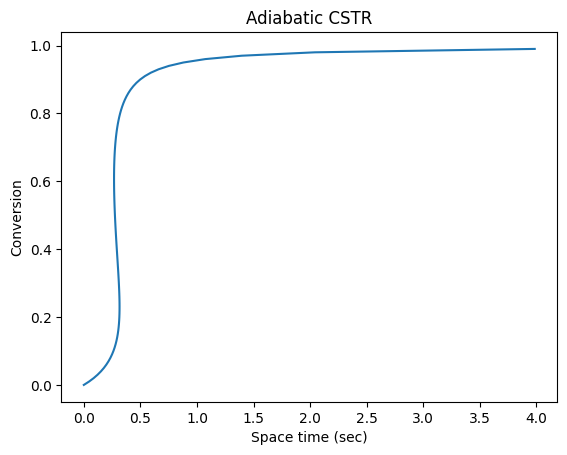

In [14]:
from scipy import optimize

def tau_adiabatic(X):
    tau = CA0 * X / (2*rate_adiabatic(X))
    return tau

def tau_root(X,tau):
    diff = tau_adiabatic(X) - tau
    return diff

Xl = np.arange(0,0.9999,0.01)
tau = tau_adiabatic(Xl)

plt.figure()
plt.plot(tau,Xl)
plt.xlabel('Space time (sec)')
plt.ylabel('Conversion')
plt.title('Adiabatic CSTR')

### Q12. What space time is necessary to achieve 90% conversion now?

0.498sec


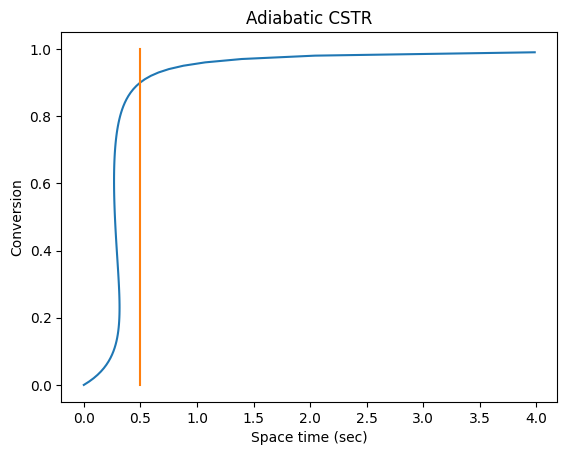

In [15]:
idx = np.argmin(np.abs(Xl - 0.9))
print(f'{tau[idx]:.3f}sec')
plt.figure()
plt.plot(tau,Xl)
plt.xlabel('Space time (sec)')
plt.ylabel('Conversion')
plt.title('Adiabatic CSTR')
plt.plot([tau[idx],tau[idx]],[0,1])

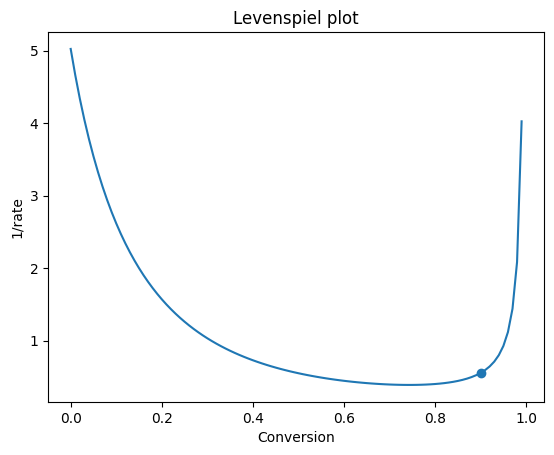

In [16]:
sol_hig = optimize.root_scalar(tau_root, bracket=[0.8, 0.99], args=(tau[idx],), method='brentq')
rate_hig = rate_adiabatic(sol_hig.root)
plt.figure()
plt.plot(Xl,1/rate_adiabatic(Xl))
plt.xlabel('Conversion')
plt.ylabel('1/rate')
plt.title('Levenspiel plot')
plt.scatter([sol_hig.root],[1/rate_hig])

### Q13. A colleague expresses concern that the CSTR might exhibit more than one steady state. Are the concerns valid? If so, what might you do to ameliorate them?

As shown in the analysis above, achieving 90% conversion corresponds to a unique value of the space-time. No special corrective actions are required in this case.